In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit, minimize
from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path

climate_data = pd.read_csv('../../data_files/data/climate_api_data_2016_2024.csv')
fire_data = pd.read_csv('../../data_files/data/inpe_fire_counts_data_2016_2024.csv')
defor_data = pd.read_csv('../../data_files/data/deter_notification_data/treated_deter_deforestation_data_2016_2024.csv')

# Merge data
climate_data = climate_data.merge(fire_data[['date', 'fire_counts']], on='date', how='left')
climate_data = climate_data.merge(defor_data[['date', 'total_degradation']], on='date', how='left')
climate_data['fire_counts'] = climate_data['fire_counts'].fillna(0)
climate_data['total_degradation'] = climate_data['total_degradation'].fillna(0)

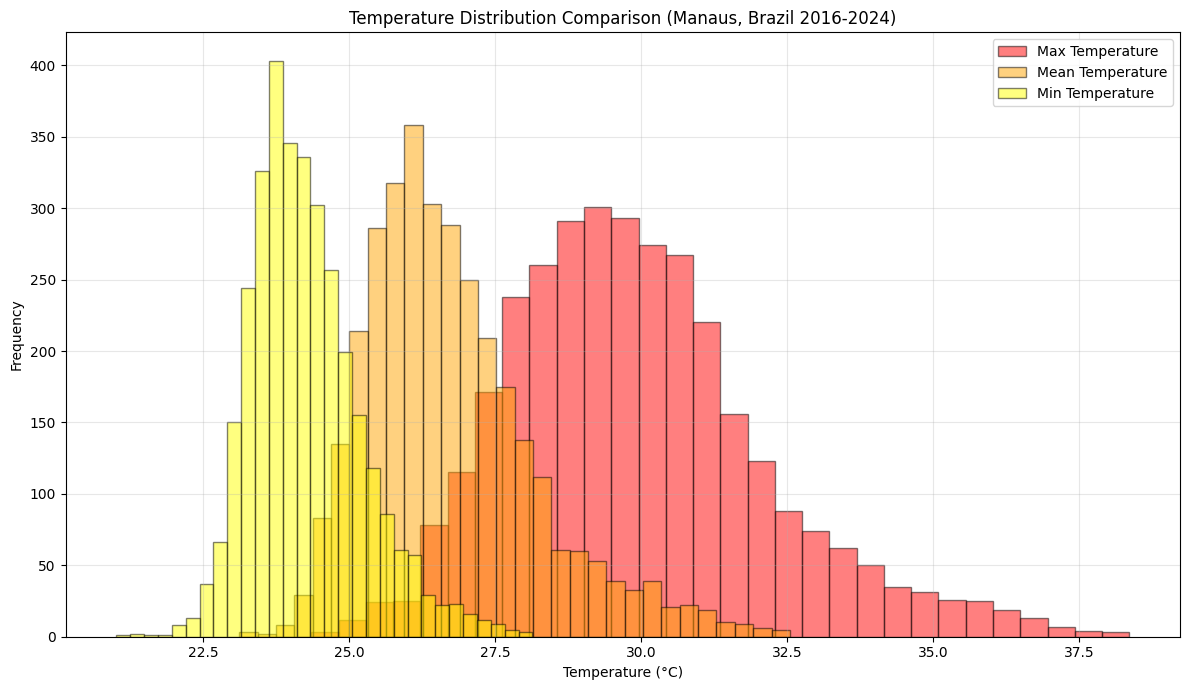

In [3]:
temp_max = climate_data['temp_max'].dropna().values
temp_med = climate_data['temp_med'].dropna().values
temp_min = climate_data['temp_min'].dropna().values

fig, ax = plt.subplots(figsize=(12, 7))

# Create histograms with transparency
ax.hist(temp_max, bins=30, alpha=0.5, edgecolor='black', label='Max Temperature', color='r')
ax.hist(temp_med, bins=30, alpha=0.5, edgecolor='black', label='Mean Temperature', color='orange')
ax.hist(temp_min, bins=30, alpha=0.5, edgecolor='black', label='Min Temperature', color='yellow')

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Frequency')
ax.set_title('Temperature Distribution Comparison (Manaus, Brazil 2016-2024)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

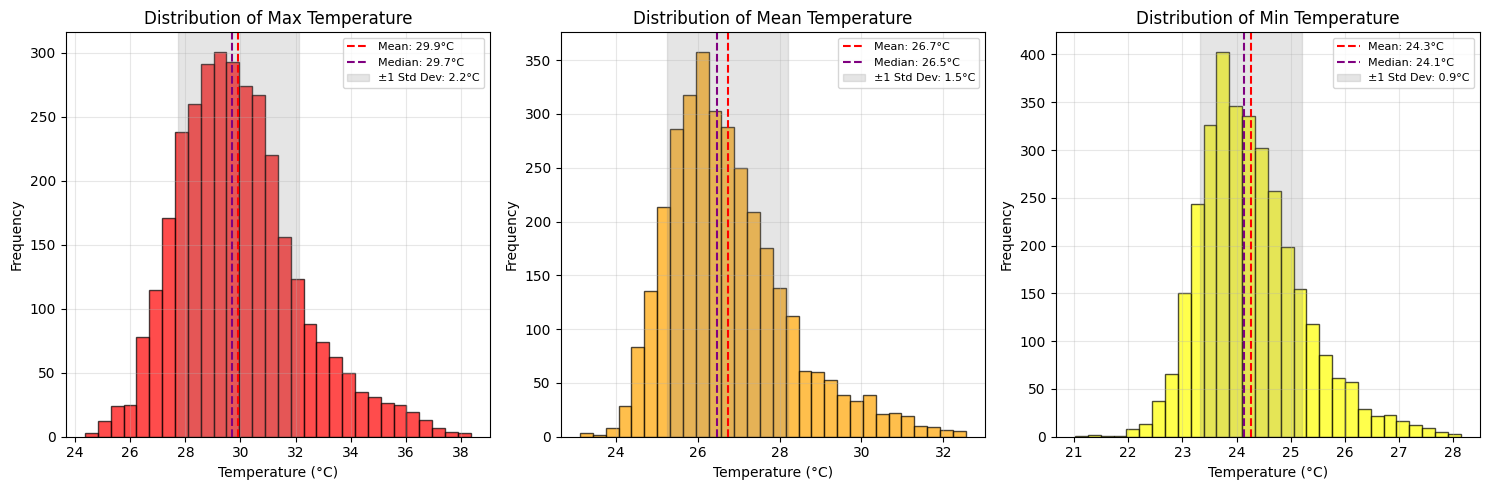

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Define temperature data and colors
temp_data = [
    (temp_max, 'Max Temperature', 'r'),
    (temp_med, 'Mean Temperature', 'orange'),
    (temp_min, 'Min Temperature', 'yellow')
]

for ax, (data, title, color) in zip(axes, temp_data):
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color=color)
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {title}')
    ax.grid(True, alpha=0.3)
    
    # Calculate statistics
    mean_val = np.mean(data)
    median_val = np.median(data)
    std_val = np.std(data)
    
    # Add mean and median lines
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}°C')
    ax.axvline(median_val, color='purple', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.1f}°C')
    
    # Add shaded region for ±1 standard deviation
    ax.axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='gray', 
               label=f'±1 Std Dev: {std_val:.1f}°C')
    
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

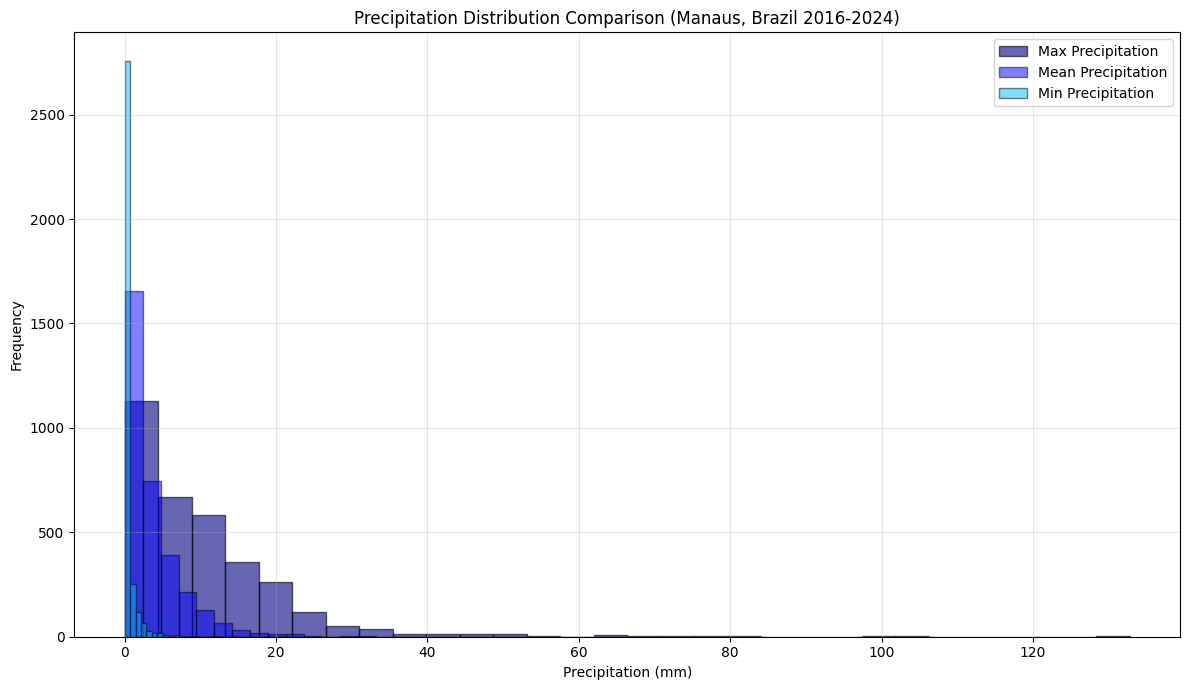

In [5]:
precip_max = climate_data['precip_max'].dropna().values
precip_med = climate_data['precip_med'].dropna().values
precip_min = climate_data['precip_min'].dropna().values

fig, ax = plt.subplots(figsize=(12, 7))

# Create histograms with transparency
ax.hist(precip_max, bins=30, alpha=0.6, edgecolor='black', label='Max Precipitation', color='navy')
ax.hist(precip_med, bins=30, alpha=0.5, edgecolor='black', label='Mean Precipitation', color='blue')
ax.hist(precip_min, bins=30, alpha=0.5, edgecolor='black', label='Min Precipitation', color='deepskyblue')

ax.set_xlabel('Precipitation (mm)')
ax.set_ylabel('Frequency')
ax.set_title('Precipitation Distribution Comparison (Manaus, Brazil 2016-2024)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

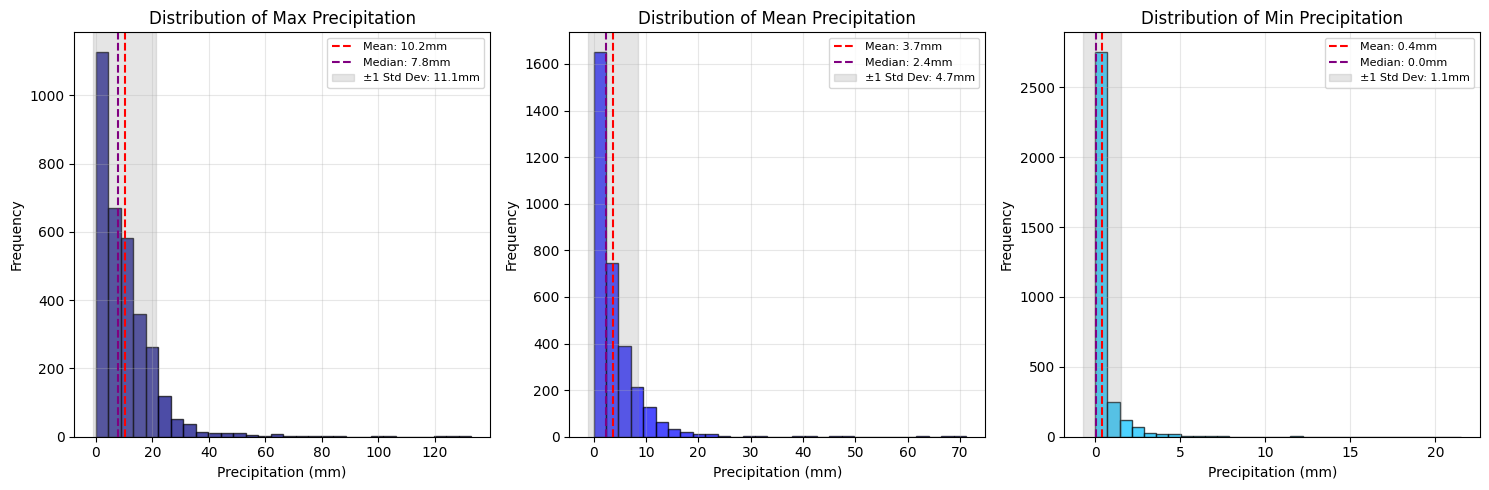

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Define precipitation data and colors
precip_data = [
    (precip_max, 'Max Precipitation', 'navy'),
    (precip_med, 'Mean Precipitation', 'blue'),
    (precip_min, 'Min Precipitation', 'deepskyblue')
]

for ax, (data, title, color) in zip(axes, precip_data):
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color=color)
    ax.set_xlabel('Precipitation (mm)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {title}')
    ax.grid(True, alpha=0.3)
    
    # Calculate statistics
    mean_val = np.mean(data)
    median_val = np.median(data)
    std_val = np.std(data)
    
    # Add mean and median lines
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}mm')
    ax.axvline(median_val, color='purple', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.1f}mm')
    
    # Add shaded region for ±1 standard deviation
    ax.axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='gray', 
               label=f'±1 Std Dev: {std_val:.1f}mm')
    
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

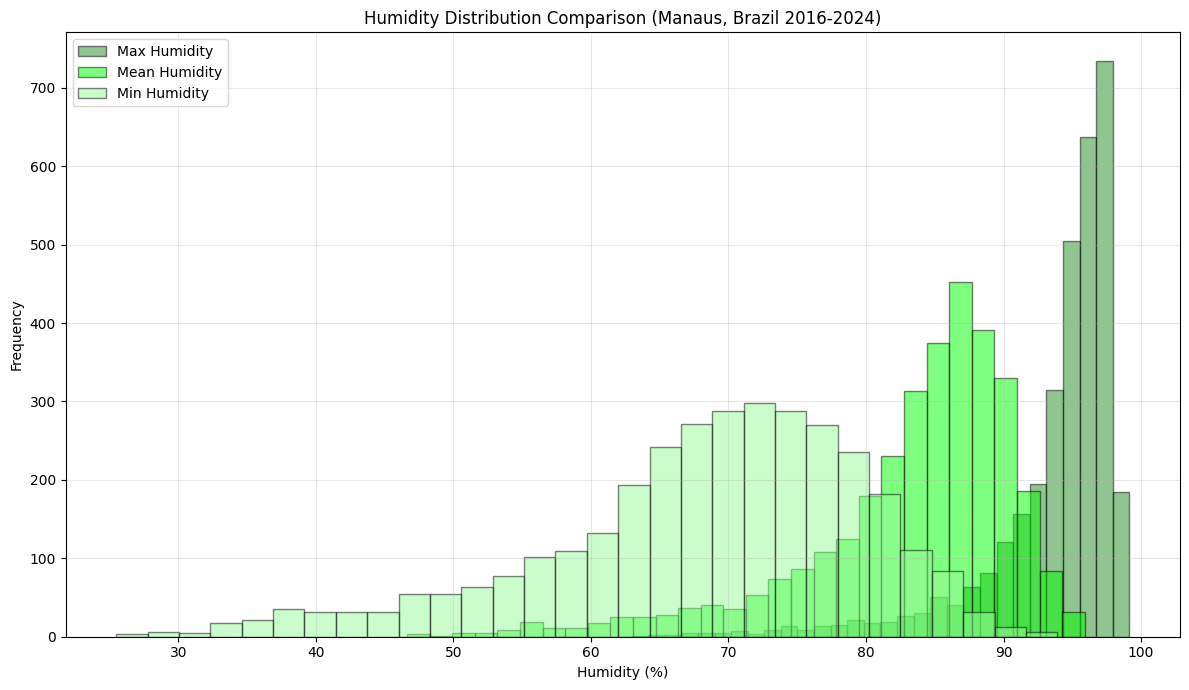

In [7]:
humid_max = climate_data['umid_max'].dropna().values
humid_med = climate_data['umid_med'].dropna().values
humid_min = climate_data['umid_min'].dropna().values

fig, ax = plt.subplots(figsize=(12, 7))

# Create histograms with transparency
ax.hist(humid_max, bins=30, alpha=0.5, edgecolor='black', label='Max Humidity', color='forestgreen')
ax.hist(humid_med, bins=30, alpha=0.5, edgecolor='black', label='Mean Humidity', color='lime')
ax.hist(humid_min, bins=30, alpha=0.5, edgecolor='black', label='Min Humidity', color='palegreen')

ax.set_xlabel('Humidity (%)')
ax.set_ylabel('Frequency')
ax.set_title('Humidity Distribution Comparison (Manaus, Brazil 2016-2024)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

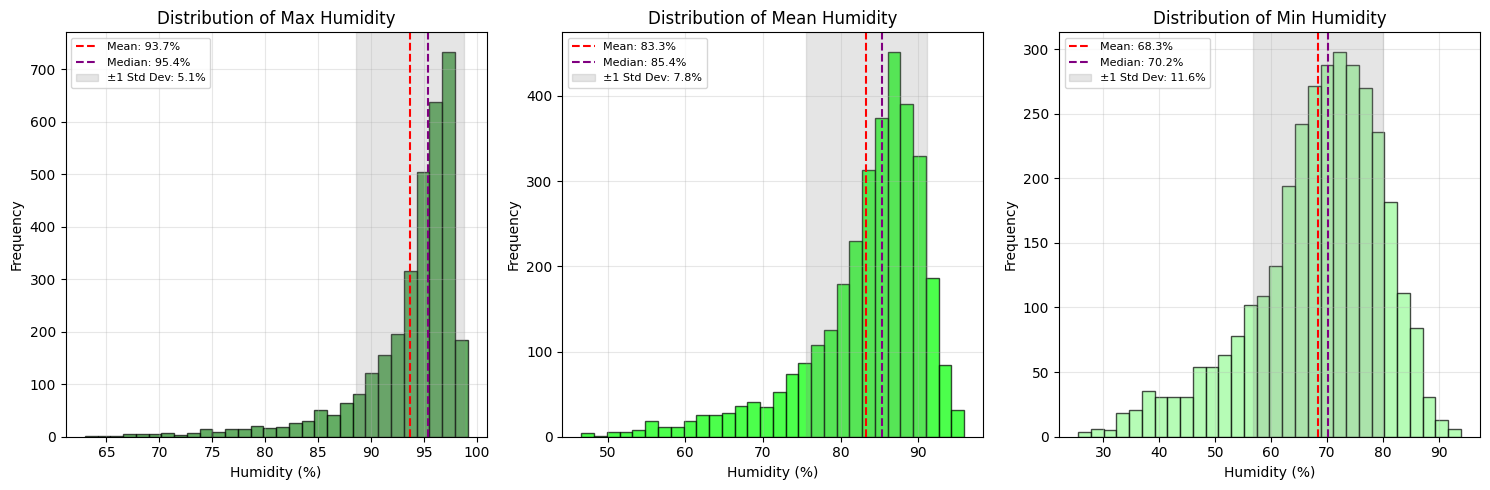

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Define humidity data and colors
humid_data = [
    (humid_max, 'Max Humidity', 'forestgreen'),
    (humid_med, 'Mean Humidity', 'lime'),
    (humid_min, 'Min Humidity', 'palegreen')
]

for ax, (data, title, color) in zip(axes, humid_data):
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color=color)
    ax.set_xlabel('Humidity (%)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {title}')
    ax.grid(True, alpha=0.3)
    
    # Calculate statistics
    mean_val = np.mean(data)
    median_val = np.median(data)
    std_val = np.std(data)
    
    # Add mean and median lines
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}%')
    ax.axvline(median_val, color='purple', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.1f}%')
    
    # Add shaded region for ±1 standard deviation
    ax.axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='gray', 
               label=f'±1 Std Dev: {std_val:.1f}%')
    
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# Humidity Distribution and Survival in Manaus
# ============================================================

climate_data['date'] = pd.to_datetime(climate_data['date'])
climate_data['month'] = climate_data['date'].dt.month
climate_data['year'] = climate_data['date'].dt.year
months_labels = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

# p_H functions
def p_H_original(Humid):
    Humid = np.asarray(Humid, dtype=float)
    return np.where(Humid < 50, 0.0, np.where(Humid < 60, (Humid - 50) / 10, 1.0))

def p_H_sigmoid(Humid, H0=58, k=0.25):
    Humid = np.asarray(Humid, dtype=float)
    return 1.0 / (1.0 + np.exp(-k * (Humid - H0)))

def p_H_sigmoid_floor(Humid, H0=58, k=0.25, phi=0.05):
    """
    Low humidity penalty function with floor.
    
    Parameters:
    -----------
    Humid : array
        Minimum daily humidity (%)
    H0 : float
        Humidity at 50% penalty (inflection point)
    k : float
        Steepness of the penalty curve
    phi : float
        Minimum value (baseline survival at very low humidity)
    """
    Humid = np.asarray(Humid, dtype=float)
    # Sigmoid increasing from floor to 1
    
    return phi + (1.0 - phi) / (1.0 + np.exp(-k * (Humid - H0)))

def p_H_martens(Humid, H0=58, k=0.25):
    Humid = np.asarray(Humid, dtype=float)
    x = (Humid - (H0 - 10)) / 10.0
    x = np.clip(x, 0, None)

    return np.where(Humid < H0 - 10, 0.0, np.where(Humid < H0, x**1.5, 1.0))

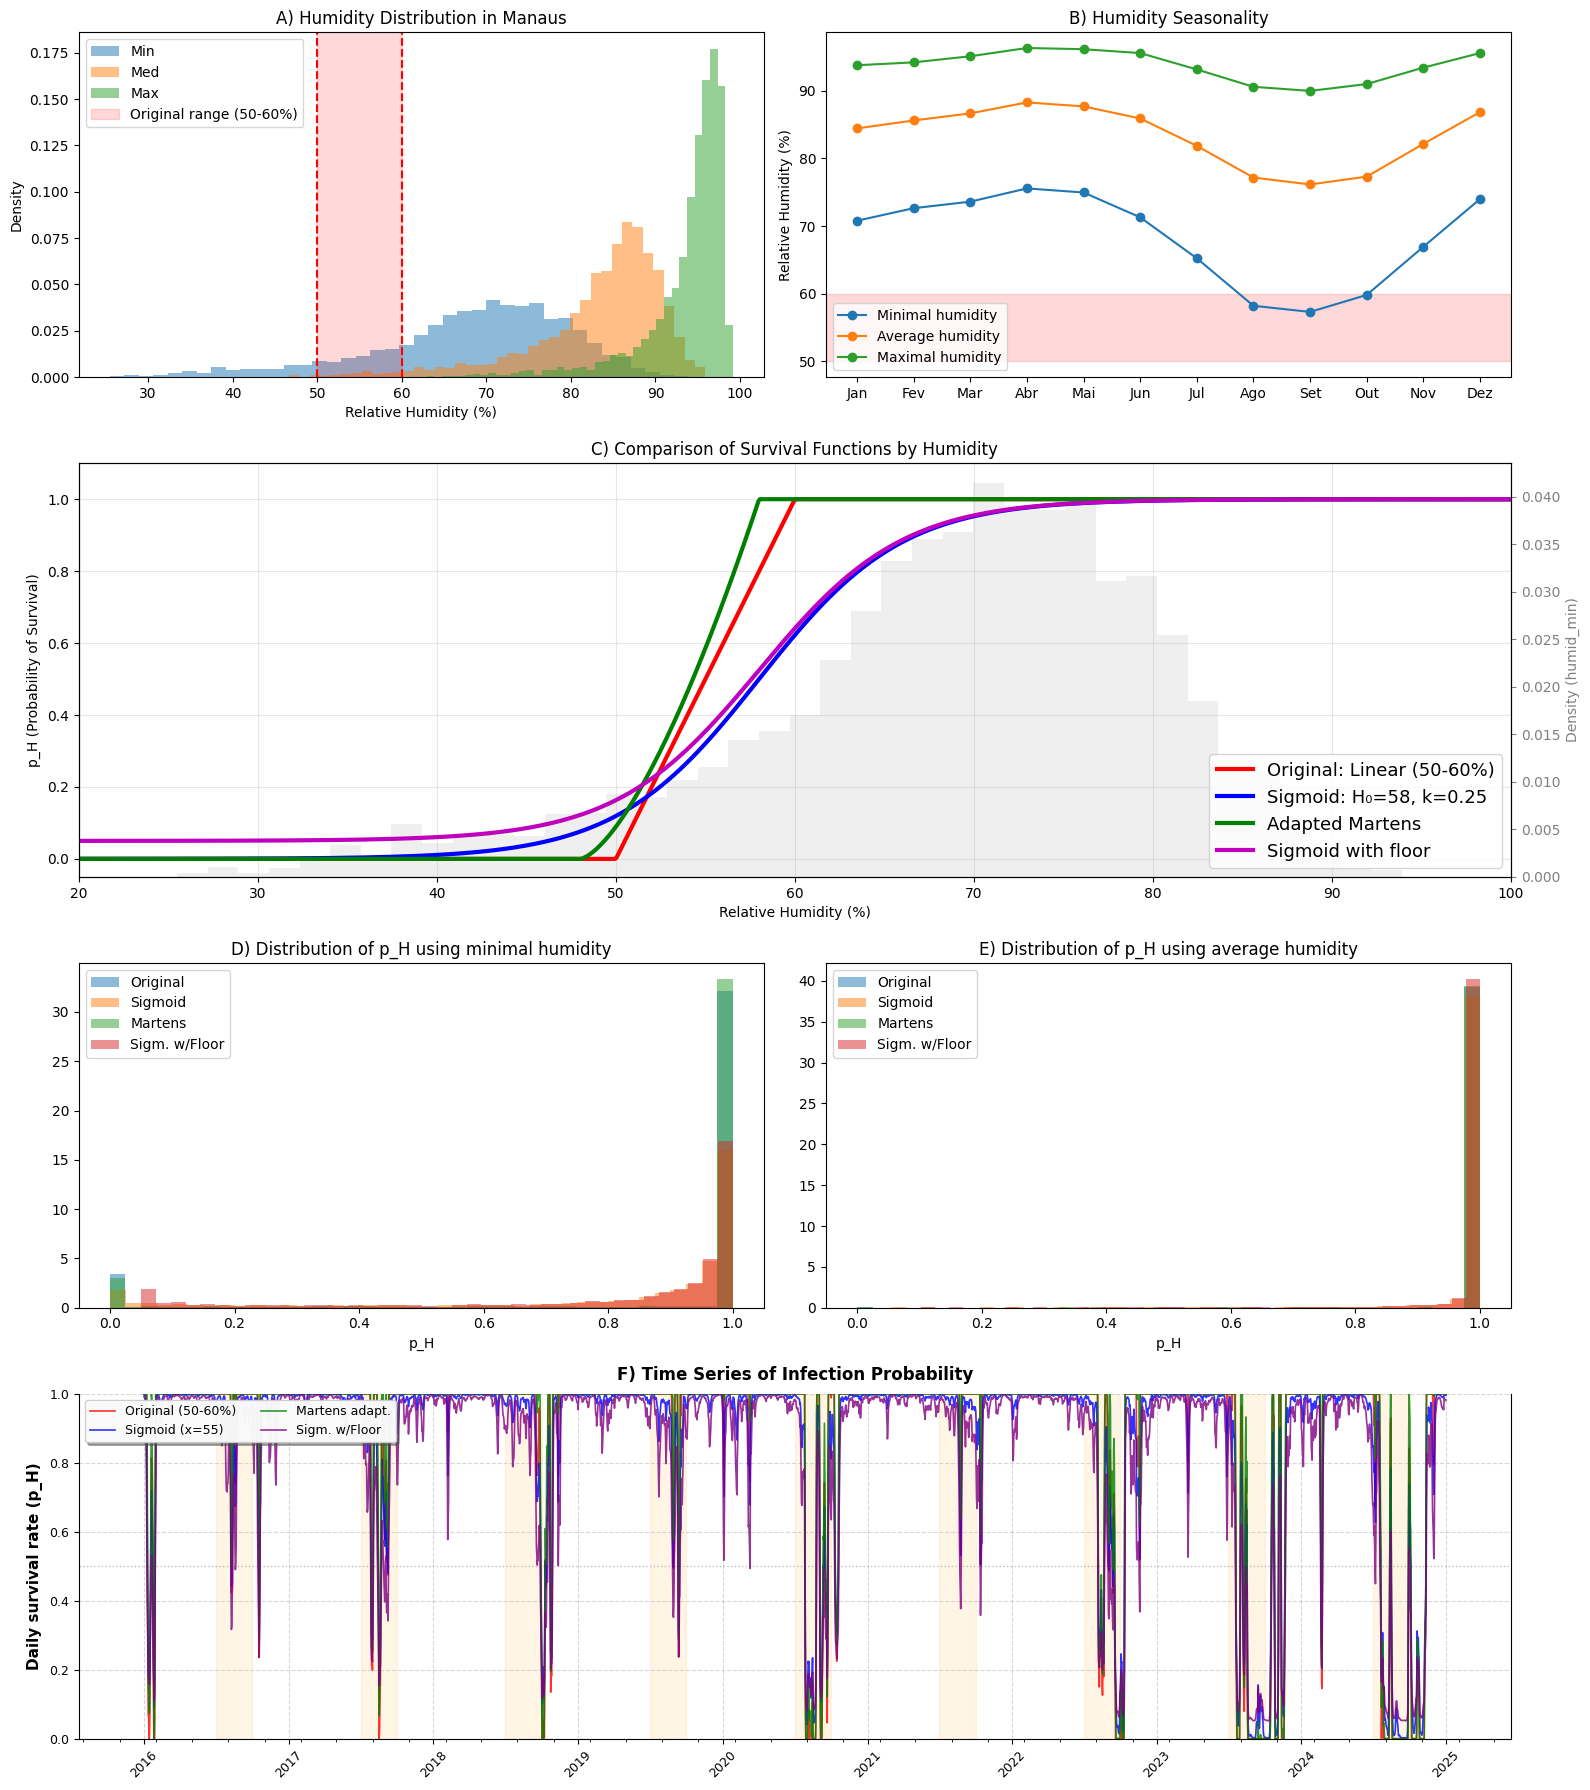

In [10]:
monthly_stats = climate_data.groupby('month').agg({
    'umid_min':'mean',
    'umid_med':'mean',
    'umid_max':'mean'
}).reset_index()

fig = plt.figure(figsize=(16,18))

gs = fig.add_gridspec(
    4, 2,
    height_ratios=[1,1.2,1,1]
)

# =========================================================
# A) Humidity distribution
# =========================================================

axA = fig.add_subplot(gs[0,0])

axA.hist(climate_data['umid_min'],
         bins=40, density=True,
         alpha=0.5, label='Min')

axA.hist(climate_data['umid_med'],
         bins=40, density=True,
         alpha=0.5, label='Med')

axA.hist(climate_data['umid_max'],
         bins=40, density=True,
         alpha=0.5, label='Max')

axA.axvline(50, color='red', linestyle='--')
axA.axvline(60, color='red', linestyle='--')

axA.axvspan(50, 60,
            color='red',
            alpha=0.15,
            label='Original range (50-60%)')

axA.set_title('A) Humidity Distribution in Manaus')
axA.set_xlabel('Relative Humidity (%)')
axA.set_ylabel('Density')
axA.legend()

# =========================================================
# B) Humidity seasonality
# =========================================================

axB = fig.add_subplot(gs[0,1])

m = monthly_stats['month']

# axB.fill_between(
#     m,
#     monthly_stats['umid_min'],
#     monthly_stats['umid_max'],
#     alpha=0.2,
#     label='Range'
# )

axB.plot(m,
         monthly_stats['umid_min'],
         'o-',
         label='Minimal humidity')

axB.plot(m,
         monthly_stats['umid_med'],
         'o-',
         label='Average humidity')

axB.plot(m,
         monthly_stats['umid_max'],
         'o-',
         label='Maximal humidity')

axB.axhspan(50,60,
            color='red',
            alpha=0.15)

axB.set_xticks(range(1,13))
axB.set_xticklabels(months_labels)

axB.set_ylabel('Relative Humidity (%)')
axB.set_title('B) Humidity Seasonality')
axB.legend()

# ======================================================
# C) Comparison between different survival rate functions
# ======================================================

axC = fig.add_subplot(gs[1,:])

H = np.linspace(20,100,1000)

axC2 = axC.twinx()

axC2.hist(
    climate_data['umid_min'],
    bins=40,
    density=True,
    color='lightgray',
    alpha=0.35
)

axC2.set_ylabel('Density (humid_min)', color='gray')
axC2.tick_params(axis='y', colors='gray')

axC.set_zorder(2)
axC.patch.set_alpha(0)

axC.plot(H,
         p_H_original(H),
         color='red',
         lw=3,
         label='Original: Linear (50-60%)')

axC.plot(H,
         p_H_sigmoid(H, H0=58, k=0.25),
         color='blue',
         lw=3,
         label='Sigmoid: H₀=58, k=0.25')

axC.plot(H,
         p_H_martens(H),
         color='green',
         lw=3,
         label='Adapted Martens')

axC.plot(H,
         p_H_sigmoid_floor(H, H0=58, k=0.25, phi=0.05),
         color='m',
         lw=3,
         label='Sigmoid with floor')

# axC.axvspan(
#     40, 75,
#     color='orange',
#     alpha=0.08
# )

# axC.text(
#     45,
#     0.5,
#     'Critical region\nfor An. darlingi',
#     color='darkorange',
#     ha='center',
#     va='center',
#     fontsize=14,
#     style='italic'
# )

axC.set_xlim(20,100)
axC.set_ylim(-0.05,1.1)

axC.set_xlabel('Relative Humidity (%)')
axC.set_ylabel('p_H (Probability of Survival)')
axC.set_title('C) Comparison of Survival Functions by Humidity')

axC.legend(loc='lower right', fontsize=13)

axC.grid(alpha=0.3)

# ======================================================
# D) Distribution of p_H using minimal humidity
# ======================================================

climate_data['pH_orig_min'] = p_H_original(climate_data['umid_min'])
climate_data['pH_sig_min'] = p_H_sigmoid(climate_data['umid_min'])
climate_data['pH_mart_min'] = p_H_martens(climate_data['umid_min'])
climate_data['pH_floor_min'] = p_H_sigmoid_floor(climate_data['umid_min'])

climate_data['pH_orig_med'] = p_H_original(climate_data['umid_med'])
climate_data['pH_sig_med'] = p_H_sigmoid(climate_data['umid_med'])
climate_data['pH_mart_med'] = p_H_martens(climate_data['umid_med'])
climate_data['pH_floor_med'] = p_H_sigmoid_floor(climate_data['umid_med'])

# climate_data['pH_orig_max'] = p_H_original(climate_data['umid_max'])
# climate_data['pH_sig_max'] = p_H_sigmoid(climate_data['umid_max'])
# climate_data['pH_mart_max'] = p_H_martens(climate_data['umid_max'])
# climate_data['pH_floor_max'] = p_H_sigmoid_floor(climate_data['umid_max'])

axD = fig.add_subplot(gs[2,0])

for col, label in [
    ('pH_orig_min','Original'),
    ('pH_sig_min','Sigmoid'),
    ('pH_mart_min','Martens'),
    ('pH_floor_min','Sigm. w/Floor')
]:
    axD.hist(climate_data[col],
             bins=40,
             density=True,
             alpha=0.5,
             label=label)

axD.set_title('D) Distribution of p_H using minimal humidity')
axD.set_xlabel('p_H')
axD.legend()

# ======================================================
# E) Distribution of p_H using average humidity
# ======================================================

axE = fig.add_subplot(gs[2,1])

for col, label in [
    ('pH_orig_med','Original'),
    ('pH_sig_med','Sigmoid'),
    ('pH_mart_med','Martens'),
    ('pH_floor_med','Sigm. w/Floor')
]:
    axE.hist(climate_data[col],
             bins=40,
             density=True,
             alpha=0.5,
             label=label)

axE.set_title('E) Distribution of p_H using average humidity')
axE.set_xlabel('p_H')
axE.legend()

# ======================================================
# F) Time Series
# ======================================================

climate_data['umid_min_smooth'] = (
    climate_data['umid_min']
    .rolling(window=7, center=True, min_periods=1)
    .mean()
)

climate_data['pH_orig_min'] = p_H_original(climate_data['umid_min_smooth'])

climate_data['pH_sig_min'] = p_H_sigmoid(
    climate_data['umid_min_smooth'],
    H0=55,
    k=0.30
)

climate_data['pH_mart_min'] = p_H_martens(
    climate_data['umid_min_smooth']
)

climate_data['pH_floor_min'] = p_H_sigmoid_floor(
    climate_data['umid_min_smooth'],
    H0=58,
    k=0.25,
    phi=0.05
)

axF = fig.add_subplot(gs[3,:])

colors = ['red', 'blue', 'green', 'purple'] 
line_styles = ['-', '-', '-', '-']
linewidth = 1.2  

axF.plot(climate_data['date'],
         climate_data['pH_orig_min'],
         lw=linewidth, alpha=0.8, color=colors[0], linestyle=line_styles[0],
         label='Original (50-60%)')

axF.plot(climate_data['date'],
         climate_data['pH_sig_min'],
         lw=linewidth, alpha=0.8, color=colors[1], linestyle=line_styles[1],
         label='Sigmoid (x=55)')

axF.plot(climate_data['date'],
         climate_data['pH_mart_min'],
         lw=linewidth, alpha=0.8, color=colors[2], linestyle=line_styles[2],
         label='Martens adapt.')

axF.plot(climate_data['date'],
         climate_data['pH_floor_min'],
         lw=linewidth, alpha=0.8, color=colors[3], linestyle=line_styles[3],
         label='Sigm. w/Floor')

# Highlighting dry seasons 
for year in climate_data['year'].unique():
    axF.axvspan(
        pd.Timestamp(year=int(year), month=7, day=1),
        pd.Timestamp(year=int(year), month=10, day=1),
        color='#FFA500',  
        alpha=0.1,  
        zorder=0  
    )

axF.set_ylim(0, 1)
axF.set_ylabel('Daily survival rate (p_H)', fontsize=11, fontweight='semibold')
axF.set_title('F) Time Series of Infection Probability', fontsize=12, fontweight='bold', pad=10)

axF.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
axF.set_axisbelow(True) 

axF.legend(loc='upper left', frameon=True, fancybox=True, shadow=True, 
           fontsize=9, framealpha=0.95, ncol=2)  

axF.xaxis.set_major_locator(mdates.YearLocator())
axF.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axF.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
axF.tick_params(axis='x', rotation=45, labelsize=9)
axF.tick_params(axis='y', labelsize=9)

axF.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1, zorder=0)

axF.spines['top'].set_visible(False)
axF.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

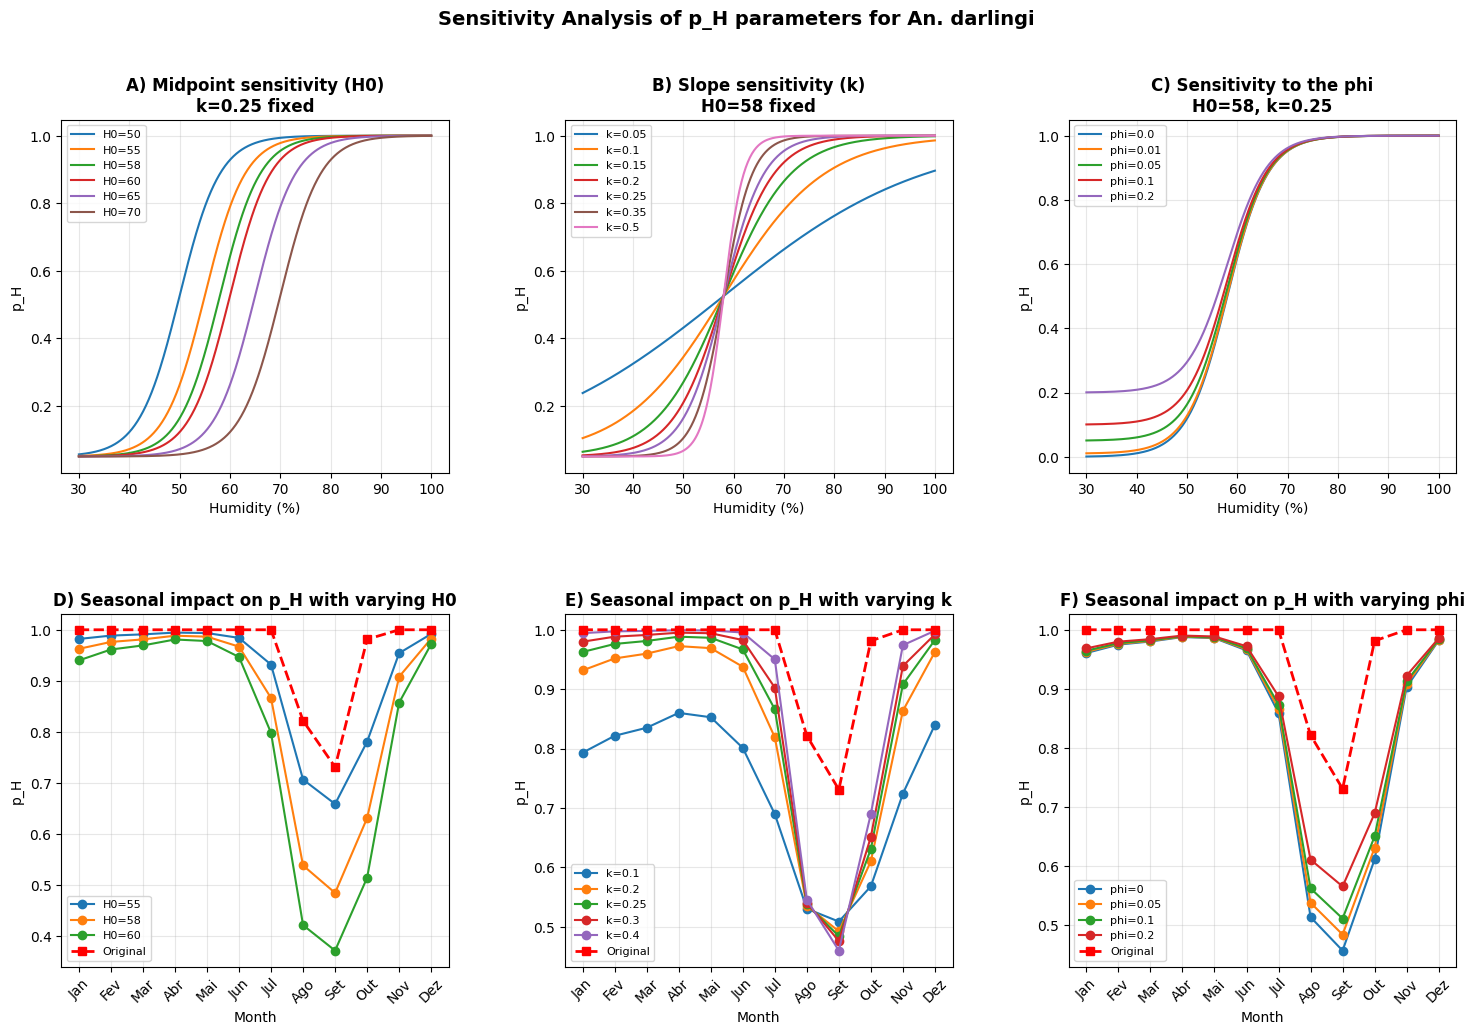

In [11]:
# ============================================================
# Sensitivity Analysis of Parameters
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
umid_range = np.linspace(30, 100, 500)

# A) Sensibility to H0
ax = axes[0, 0]
for H0 in [50, 55, 58, 60, 65, 70]:
    ax.plot(umid_range, p_H_sigmoid_floor(umid_range, H0=H0, k=0.25), label=f'H0={H0}')
ax.set_xlabel('Humidity (%)')
ax.set_ylabel('p_H')
ax.set_title('A) Midpoint sensitivity (H0)\nk=0.25 fixed', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# B) Sensibility to k
ax = axes[0, 1]
for k in [0.05, 0.10, 0.15, 0.20, 0.25, 0.35, 0.50]:
    ax.plot(umid_range, p_H_sigmoid_floor(umid_range, H0=58, k=k), label=f'k={k}')
ax.set_xlabel('Humidity (%)')
ax.set_ylabel('p_H')
ax.set_title('B) Slope sensitivity (k)\nH0=58 fixed', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# C) Sensibility to the phi
ax = axes[0, 2]
for phi in [0.0, 0.01, 0.05, 0.10, 0.20]:
    ax.plot(umid_range, p_H_sigmoid_floor(umid_range, H0=58, k=0.25, phi=phi), label=f'phi={phi}')
ax.set_xlabel('Humidity (%)')
ax.set_ylabel('p_H')
ax.set_title('C) Sensitivity to the phi\nH0=58, k=0.25', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# D) Seasonal impact of H0
ax = axes[1, 0]
monthly_min_mean = climate_data.groupby('month')['umid_min'].mean()
for H0 in [55, 58, 60]:
    ax.plot(months_labels, p_H_sigmoid_floor(monthly_min_mean.values, H0=H0, k=0.25, phi=0.05), 'o-', label=f'H0={H0}')
ax.plot(months_labels, p_H_original(monthly_min_mean.values), 's--', color='red', linewidth=2, label='Original')
ax.set_xlabel('Month')
ax.set_ylabel('p_H')
ax.set_title('D) Seasonal impact on p_H with varying H0', fontweight='bold')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# E) Seasonal impact of k
ax = axes[1, 1]
for k in [0.1, 0.2, 0.25, 0.3, 0.4]:
    ax.plot(months_labels, p_H_sigmoid_floor(monthly_min_mean.values, H0=58, k=k, phi=0.05), 'o-', label=f'k={k}')
ax.plot(months_labels, p_H_original(monthly_min_mean.values), 's--', color='red', linewidth=2, label='Original')
ax.set_xlabel('Month')
ax.set_ylabel('p_H')
ax.set_title('E) Seasonal impact on p_H with varying k', fontweight='bold')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

# F) Seasonal impact of phi
ax = axes[1, 2]
for phi in [0, 0.05, 0.1, 0.2]:
    ax.plot(months_labels, p_H_sigmoid_floor(monthly_min_mean.values, H0=58, k=0.25, phi=phi), 'o-', label=f'phi={phi}')
ax.plot(months_labels, p_H_original(monthly_min_mean.values), 's--', color='red', linewidth=2, label='Original')
ax.set_xlabel('Month')
ax.set_ylabel('p_H')
ax.set_title('F) Seasonal impact on p_H with varying phi', fontweight='bold')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

plt.suptitle('Sensitivity Analysis of p_H parameters for An. darlingi', fontsize=14, fontweight='bold')
#plt.savefig('humidity_sensitivity.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [12]:
def p_H_high_original(Humid, H0=99, k=0.08):
    return 1.0 / (1.0 + np.exp(k * (Humid - H0)))

def p_H_sigmoid_ceil(Humid, H0=99, k=0.08, psi=0.3):
    """
    High humidity penalty function with ceiling.
    
    Parameters:
    -----------
    Humid: array
        Maximum daily humidity (%)
    H0: float
        Humidity at 50% penalty (inflection point)
    k: float
        Steepness of the penalty curve
    psi: float
        Minimum value (baseline survival at very high humidity)
    """
    Humid = np.asarray(Humid, dtype=float)
    # Sigmoid decreasing from 1 to ceiling
    
    return psi + (1.0 - psi) / (1.0 + np.exp(k * (Humid - H0)))

# Alternative: Same structure as p_H_sigmoid_floor but decreasing
def p_H_high_symmetric(Humid, H0=95, k=0.15, psi=0.4):
    """
    Alternative: Symmetric sigmoid for high humidity penalty
    """
    Humid = np.asarray(Humid, dtype=float)
    # Decreases from 1 to ceiling
    return 1 - (1 - psi) / (1.0 + np.exp(-k * (Humid - H0)))

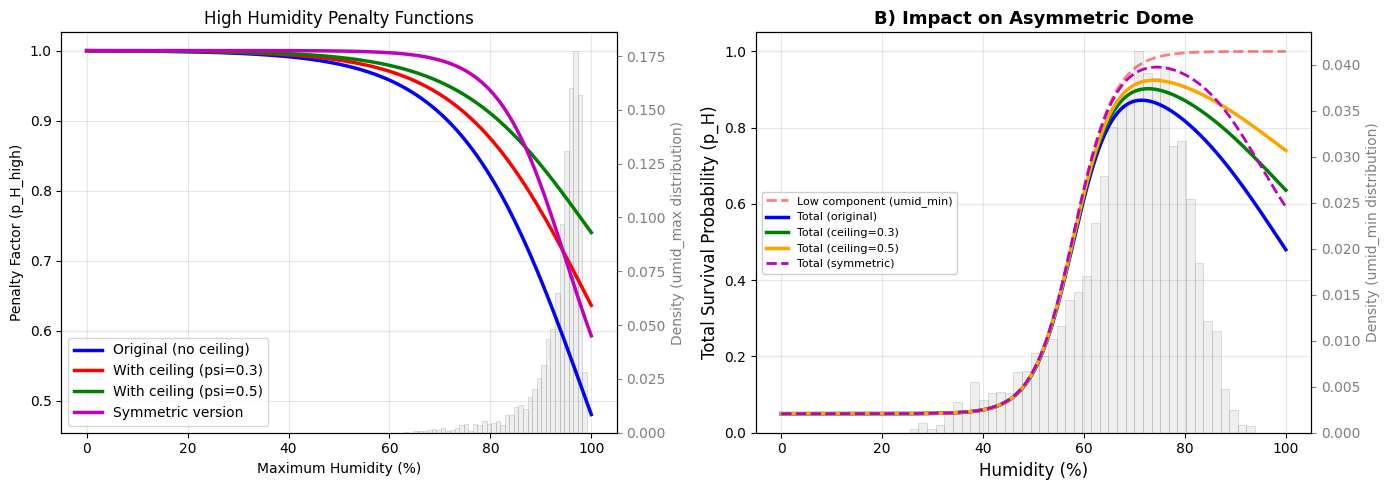

In [13]:
H = np.linspace(0, 100, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Different high-humidity functions
ax1 = axes[0]

ax1_hist = ax1.twinx()
ax1_hist.hist(humid_max, bins=40, density=True, color='lightgray', alpha=0.35, edgecolor='gray', linewidth=0.5)
ax1_hist.set_ylabel('Density (umid_max distribution)', color='gray', fontsize=10)
ax1_hist.tick_params(axis='y', colors='gray')

# Bring main axis to front
ax1.set_zorder(2)
ax1.patch.set_alpha(0)

ax1.plot(H, p_H_high_original(H), 'b-', lw=2.5, label='Original (no ceiling)')
ax1.plot(H, p_H_sigmoid_ceil(H, psi=0.3), 'r-', lw=2.5, label='With ceiling (psi=0.3)')
ax1.plot(H, p_H_sigmoid_ceil(H, psi=0.5), 'g-', lw=2.5, label='With ceiling (psi=0.5)')
ax1.plot(H, p_H_high_symmetric(H), 'm-', lw=2.5, label='Symmetric version')

# ax1.axvline(humid_max.mean(), color='blue', linestyle=':', alpha=0.7, label=f'Mean: {humid_max.mean():.1f}%')
# ax1.axvline(np.percentile(humid_max, 50), color='darkblue', linestyle=':', alpha=0.7, label=f'Median: {np.percentile(humid_max, 50):.1f}%')

ax1.set_xlabel('Maximum Humidity (%)')
ax1.set_ylabel('Penalty Factor (p_H_high)')
ax1.set_title('High Humidity Penalty Functions')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Impact on total survival (asymmetric dome)
ax2 = axes[1]

# Create twin axis for histogram (umid_min distribution)
ax2_hist = ax2.twinx()
ax2_hist.hist(humid_min, bins=40, density=True, color='lightgray', alpha=0.35, edgecolor='gray', linewidth=0.5)
ax2_hist.set_ylabel('Density (umid_min distribution)', color='gray', fontsize=10)
ax2_hist.tick_params(axis='y', colors='gray')

# Bring main axis to front
ax2.set_zorder(2)
ax2.patch.set_alpha(0)

# Calculate total survival with different high functions
p_low = p_H_sigmoid_floor(H)

p_total_original = p_low * p_H_high_original(H)
p_total_ceiling_03 = p_low * p_H_sigmoid_ceil(H, psi=0.3)
p_total_ceiling_05 = p_low * p_H_sigmoid_ceil(H, psi=0.5)
p_total_symmetric = p_low * p_H_high_symmetric(H)

ax2.plot(H, p_low, 'r--', lw=2, alpha=0.5, label='Low component (umid_min)')
ax2.plot(H, p_total_original, 'b-', lw=2.5, label='Total (original)')
ax2.plot(H, p_total_ceiling_03, 'g-', lw=2.5, label='Total (ceiling=0.3)')
ax2.plot(H, p_total_ceiling_05, 'orange', lw=2.5, label='Total (ceiling=0.5)')
ax2.plot(H, p_total_symmetric, 'm--', lw=2, label='Total (symmetric)')

# # Add vertical lines for key humidity statistics (umid_min)
# ax2.axvline(humid_min.mean(), color='red', linestyle=':', alpha=0.7, linewidth=2, label=f'Mean umid_min: {humid_min.mean():.1f}%')
# ax2.axvline(np.percentile(humid_min, 50), color='darkred', linestyle=':', alpha=0.7, linewidth=2, label=f'Median umid_min: {np.percentile(humid_min, 50):.1f}%')

# # Highlight optimal humidity range
# ax2.axvspan(70, 85, color='green', alpha=0.1, label='Optimal range (70-85%)')

# # Add text annotation in optimal zone
# ax2.text(77, 0.6, 'Optimal\nhumidity zone', 
#          color='darkgreen', ha='center', va='center', fontsize=9, style='italic',
#          bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax2.set_xlabel('Humidity (%)', fontsize=12)
ax2.set_ylabel('Total Survival Probability (p_H)', fontsize=12)
ax2.set_title('B) Impact on Asymmetric Dome', fontsize=13, fontweight='bold')
ax2.legend(loc='center left', fontsize=8, framealpha=0.95)
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()